# Phân Tích Dữ Liệu Benchmark SPMC (Single Producer Multiple Consumer)

Notebook này được thiết kế để phân tích kết quả benchmark từ thư mục `benchmark/results`. 

## Mục tiêu:
- Tải và xử lý dữ liệu CSV từ các test benchmark
- Phân tích hiệu suất: throughput, latency, load balancing
- So sánh hiệu suất giữa các cấu hình khác nhau (số processes)
- Trực quan hóa kết quả để đưa ra kết luận

## Các metrics chính:
- **Throughput**: Số items xử lý được mỗi giây
- **Latency**: Thời gian enqueue/dequeue (trung bình và max)
- **Load Balance Score**: Điểm cân bằng tải
- **Memory Usage**: Sử dụng bộ nhớ peak

# 1. Import Required Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime
import warnings

# Cấu hình cho visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Tắt warnings không cần thiết
warnings.filterwarnings('ignore')

print("✅ Đã import thành công tất cả libraries cần thiết!")

✅ Đã import thành công tất cả libraries cần thiết!


# 2. Load Benchmark CSV Files

In [2]:
def load_benchmark_data(results_dir="benchmark/results"):
    """
    Tải tất cả file CSV từ thư mục benchmark/results
    Mỗi file CSV là một experiment độc lập với vai trò ngang nhau
    """
    csv_files = []
    combined_data = []
    
    print(f"🔍 Searching for CSV files in: {results_dir}")
    
    # Tìm tất cả file CSV trong các subfolder
    for root, dirs, files in os.walk(results_dir):
        for file in files:
            if file.endswith('.csv'):
                csv_path = os.path.join(root, file)
                csv_files.append(csv_path)
                
                # Đọc file CSV
                try:
                    df = pd.read_csv(csv_path)
                    
                    # Thêm metadata đơn giản từ tên file và folder
                    folder_name = os.path.basename(root)
                    file_name = os.path.splitext(file)[0]  # Remove .csv extension
                    
                    df['Source_File'] = file
                    df['Source_Folder'] = folder_name
                    
                    # Tạo Experiment_ID từ folder name hoặc file name
                    if folder_name and folder_name != os.path.basename(results_dir):
                        df['Experiment_ID'] = folder_name  # Use folder name as experiment ID
                    else:
                        df['Experiment_ID'] = file_name     # Use file name if no meaningful folder
                    
                    # Extract basic info từ folder/file name (nếu có pattern)
                    experiment_name = df['Experiment_ID'].iloc[0]
                    if '_' in experiment_name:
                        df['Experiment_Config'] = experiment_name  # Lưu full name làm config
                    
                    combined_data.append(df)
                    print(f"✅ Loaded experiment: {df['Experiment_ID'].iloc[0]} ({len(df)} records)")
                    
                except Exception as e:
                    print(f"❌ Error loading {csv_path}: {e}")
    
    if combined_data:
        # Kết hợp tất cả data
        all_data = pd.concat(combined_data, ignore_index=True)
        print(f"\n📊 Successfully loaded {len(csv_files)} files")
        print(f"📈 Total records: {len(all_data)}")
        print(f"🧪 Unique experiments: {all_data['Experiment_ID'].nunique()}")
        return all_data, csv_files
    else:
        print("❌ Không tìm thấy file CSV nào!")
        print(f"📁 Checked directory: {os.path.abspath(results_dir)}")
        return None, []

# Load data
print("🚀 Loading benchmark data...")
df_combined, file_list = load_benchmark_data()

if df_combined is not None:
    print(f"\n🎯 Dataset shape: {df_combined.shape}")
    print(f"📋 Columns: {list(df_combined.columns)}")
    
    # Debug info
    if 'Experiment_ID' in df_combined.columns:
        print(f"\n🧪 Experiments found:")
        for exp_id in df_combined['Experiment_ID'].unique():
            exp_data = df_combined[df_combined['Experiment_ID'] == exp_id]
            print(f"  • {exp_id}: {len(exp_data)} records")
    else:
        print("\n❌ Warning: Experiment_ID column not created!")
else:
    print("\n❌ Không có dữ liệu để phân tích!")
    print("💡 Kiểm tra xem:")
    print("   - Thư mục 'benchmark/results' có tồn tại không?")
    print("   - Có file CSV nào trong thư mục không?")
    print("   - Path có đúng không?")

✅ Loaded: benchmark/results\benchmark_throughput_3procs_20250707_225122\benchmark_throughput_3procs.csv
✅ Loaded: benchmark/results\spmc_2004_quick_2procs_20250707_231002\spmc_2004_quick_2procs_20250707_231002.csv
✅ Loaded: benchmark/results\spmc_2004_throughput_4procs_20250707_225337\spmc_2004_throughput_4procs_20250707_225337.csv
✅ Loaded: benchmark/results\spmc_2004_throughput_4procs_20250707_230247\spmc_2004_throughput_4procs_20250707_230247.csv

📊 Tổng cộng loaded 4 files
📈 Tổng số records: 4

🎯 Shape của combined dataset: (4, 17)
📋 Columns: ['Test_Name', 'MPI_Size', 'Total_Time_Sec', 'Items_Produced', 'Items_Consumed', 'Throughput_Items_Per_Sec', 'Avg_Enqueue_Latency_Us', 'Max_Enqueue_Latency_Us', 'Avg_Dequeue_Latency_Us', 'Max_Dequeue_Latency_Us', 'Memory_Peak_KB', 'Load_Balance_Score', 'Source_File', 'Source_Folder', 'Test_Type_Extracted', 'Processes_Extracted', 'Timestamp']


# 3. Preview và Inspect Data

In [10]:
if df_combined is not None:
    print("📋 PREVIEW DỮ LIỆU:")
    print("=" * 50)
    
    # Hiển thị 5 dòng đầu
    print("\n🔍 5 dòng đầu tiên:")
    display(df_combined.head())
    
    print("\n📊 THÔNG TIN DATASET:")
    print("=" * 30)
    
    # Kiểm tra xem có column Experiment_ID không
    if 'Experiment_ID' in df_combined.columns:
        print(f"• Số experiments: {df_combined['Experiment_ID'].nunique()}")
    else:
        print("• Số experiments: N/A (column Experiment_ID not found)")
    
    print(f"• Tổng số records: {len(df_combined)}")
    print(f"• Số cột: {len(df_combined.columns)}")
    
    print("\n📈 THÔNG TIN CÁC CỘT:")
    print("=" * 30)
    print(df_combined.info())
    
    print("\n🔢 KIỂM TRA MISSING VALUES:")
    print("=" * 35)
    missing_data = df_combined.isnull().sum()
    if missing_data.sum() == 0:
        print("✅ Không có missing values!")
    else:
        print(missing_data[missing_data > 0])
    
    print("\n⚙️ SỐ PROCESSES TRONG CÁC EXPERIMENTS:")
    print("=" * 40)
    if 'MPI_Size' in df_combined.columns:
        print(df_combined['MPI_Size'].value_counts().sort_index())
    else:
        print("❌ Column MPI_Size not found")
    
    print("\n🧪 DANH SÁCH CÁC EXPERIMENTS:")
    print("=" * 35)
    if 'Experiment_ID' in df_combined.columns:
        for exp_id in df_combined['Experiment_ID'].unique():
            exp_data = df_combined[df_combined['Experiment_ID'] == exp_id]
            mpi_size = exp_data['MPI_Size'].iloc[0] if 'MPI_Size' in exp_data.columns else 'N/A'
            throughput = exp_data['Throughput_Items_Per_Sec'].iloc[0] if 'Throughput_Items_Per_Sec' in exp_data.columns else 'N/A'
            print(f"  • {exp_id}")
            print(f"    - Processes: {mpi_size}")
            print(f"    - Throughput: {throughput} items/sec")
    else:
        print("❌ Column Experiment_ID not found")
        print("📁 Available columns:")
        print(list(df_combined.columns))
    
    print("\n📋 SAMPLE DATA:")
    print("=" * 20)
    # Hiển thị key columns từ mỗi experiment
    key_cols = ['Experiment_ID', 'MPI_Size', 'Total_Time_Sec', 'Throughput_Items_Per_Sec', 
               'Avg_Enqueue_Latency_Us', 'Avg_Dequeue_Latency_Us']
    available_cols = [col for col in key_cols if col in df_combined.columns]
    
    if available_cols:
        print(f"Available columns to display: {available_cols}")
        display(df_combined[available_cols])
    else:
        print("❌ Không tìm thấy columns cần thiết")
        print("📋 Displaying first few columns instead:")
        display(df_combined.iloc[:, :min(5, len(df_combined.columns))])
        
else:
    print("❌ Không có dữ liệu để preview!")

📋 PREVIEW DỮ LIỆU:

🔍 5 dòng đầu tiên:


,Test_Name,MPI_Size,Total_Time_Sec,Items_Produced,Items_Consumed,Throughput_Items_Per_Sec,Avg_Enqueue_Latency_Us,Max_Enqueue_Latency_Us,Avg_Dequeue_Latency_Us,Max_Dequeue_Latency_Us,Memory_Peak_KB,Load_Balance_Score,Source_File,Source_Folder,Test_Type_Extracted,Processes_Extracted,Timestamp
0,Throughput Test,3,11.698,10000,10500,897.56,22.68,116.0,0.0,1217.0,0,100,benchmark_throughput_3procs.csv,benchmark_throughput_3procs_20250707_225122,throughput,3,20250707_225122
1,Throughput Test,2,1.665,1000,1000,600.62,23.65,103.0,0.0,651.0,0,100,spmc_2004_quick_2procs_20250707_231002.csv,spmc_2004_quick_2procs_20250707_231002,2004,unknown,2procs_20250707_231002
2,Throughput Test,4,11.611,10000,10500,904.33,22.32,123.0,0.0,2295.0,0,100,spmc_2004_throughput_4procs_20250707_225337.csv,spmc_2004_throughput_4procs_20250707_225337,2004,unknown,4procs_20250707_225337
3,Throughput Test,4,11.947,10000,10500,878.90,24.62,614.0,0.0,2431.0,0,99,spmc_2004_throughput_4procs_20250707_230247.csv,spmc_2004_throughput_4procs_20250707_230247,2004,unknown,4procs_20250707_230247



📊 THÔNG TIN DATASET:
• Số experiments: N/A (column Experiment_ID not found)
• Tổng số records: 4
• Số cột: 17

📈 THÔNG TIN CÁC CỘT:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Test_Name                 4 non-null      object 
 1   MPI_Size                  4 non-null      int64  
 2   Total_Time_Sec            4 non-null      float64
 3   Items_Produced            4 non-null      int64  
 4   Items_Consumed            4 non-null      int64  
 5   Throughput_Items_Per_Sec  4 non-null      float64
 6   Avg_Enqueue_Latency_Us    4 non-null      float64
 7   Max_Enqueue_Latency_Us    4 non-null      float64
 8   Avg_Dequeue_Latency_Us    4 non-null      float64
 9   Max_Dequeue_Latency_Us    4 non-null      float64
 10  Memory_Peak_KB            4 non-null      int64  
 11  Load_Balance_Score        4 non-null      int6

,MPI_Size,Total_Time_Sec,Throughput_Items_Per_Sec,Avg_Enqueue_Latency_Us,Avg_Dequeue_Latency_Us
0,3,11.698,897.56,22.68,0.0
1,2,1.665,600.62,23.65,0.0
2,4,11.611,904.33,22.32,0.0
3,4,11.947,878.90,24.62,0.0


# 4. Aggregate và Summarize Results

In [12]:
if df_combined is not None:
    print("📊 SUMMARY STATISTICS")
    print("=" * 50)
    
    # Các metrics quan trọng
    key_metrics = [
        'Total_Time_Sec', 'Throughput_Items_Per_Sec', 
        'Avg_Enqueue_Latency_Us', 'Max_Enqueue_Latency_Us',
        'Avg_Dequeue_Latency_Us', 'Max_Dequeue_Latency_Us',
        'Load_Balance_Score'
    ]
    
    # Lọc các cột có trong dataset
    available_metrics = [col for col in key_metrics if col in df_combined.columns]
    
    if available_metrics:
        print(f"\n🎯 TỔNG QUAN CÁC METRICS:")
        print("=" * 30)
        summary_stats = df_combined[available_metrics].describe()
        display(summary_stats.round(3))
        
        print(f"\n⚙️ PERFORMANCE THEO SỐ PROCESSES:")
        print("=" * 40)
        if 'MPI_Size' in df_combined.columns:
            process_summary = df_combined.groupby('MPI_Size')[available_metrics].agg(['mean', 'std', 'min', 'max'])
            display(process_summary.round(3))
        
        print(f"\n🧪 PERFORMANCE THEO TỪNG EXPERIMENT:")
        print("=" * 40)
        if 'Experiment_ID' in df_combined.columns:
            exp_summary = df_combined.groupby('Experiment_ID')[available_metrics].mean()
            display(exp_summary.round(3))
            
        # So sánh experiments
        print(f"\n📈 SO SÁNH EXPERIMENTS:")
        print("=" * 30)
        if 'Experiment_ID' in df_combined.columns and 'Throughput_Items_Per_Sec' in df_combined.columns:
            comparison = df_combined.groupby('Experiment_ID').agg({
                'MPI_Size': 'first',
                'Throughput_Items_Per_Sec': 'mean',
                'Avg_Enqueue_Latency_Us': 'mean',
                'Total_Time_Sec': 'mean'
            }).round(3)
            
            # Sort by throughput descending
            if 'Throughput_Items_Per_Sec' in comparison.columns:
                comparison = comparison.sort_values('Throughput_Items_Per_Sec', ascending=False)
            
            print("Experiments ranked by performance:")
            display(comparison)
            
        # Best performers
        print(f"\n🏆 TOP PERFORMERS:")
        print("=" * 25)
        if 'Throughput_Items_Per_Sec' in df_combined.columns:
            top_experiments = df_combined.nlargest(3, 'Throughput_Items_Per_Sec')
            print("🚀 Highest Throughput:")
            # Only display columns that exist
            cols_to_show = [col for col in ['Experiment_ID', 'MPI_Size', 'Throughput_Items_Per_Sec', 'Total_Time_Sec'] if col in top_experiments.columns]
            display(top_experiments[cols_to_show])
        
        if 'Avg_Enqueue_Latency_Us' in df_combined.columns:
            low_latency = df_combined.nsmallest(3, 'Avg_Enqueue_Latency_Us')
            print("\n⚡ Lowest Latency:")
            cols_to_show = [col for col in ['Experiment_ID', 'MPI_Size', 'Avg_Enqueue_Latency_Us', 'Throughput_Items_Per_Sec'] if col in low_latency.columns]
            display(low_latency[cols_to_show])
    
    else:
        print("❌ Không tìm thấy metrics để phân tích!")
        
else:
    print("❌ Không có dữ liệu để phân tích!")

📊 SUMMARY STATISTICS

🎯 TỔNG QUAN CÁC METRICS:


,Total_Time_Sec,Throughput_Items_Per_Sec,Avg_Enqueue_Latency_Us,Max_Enqueue_Latency_Us,Avg_Dequeue_Latency_Us,Max_Dequeue_Latency_Us,Load_Balance_Score
count,4.000,4.000,4.000,4.000,4.0,4.000,4.00
mean,9.230,820.352,23.318,239.000,0.0,1648.500,99.75
std,5.046,146.882,1.034,250.137,0.0,858.578,0.50
min,1.665,600.620,22.320,103.000,0.0,651.000,99.00
25%,9.125,809.330,22.590,112.750,0.0,1075.500,99.75
50%,11.654,888.230,23.165,119.500,0.0,1756.000,100.00
75%,11.760,899.252,23.892,245.750,0.0,2329.000,100.00
max,11.947,904.330,24.620,614.000,0.0,2431.000,100.00



⚙️ PERFORMANCE THEO SỐ PROCESSES:


Total_Time_Sec                        Throughput_Items_Per_Sec  \
                   mean    std     min     max                     mean   
MPI_Size                                                                  
2                 1.665    NaN   1.665   1.665                  600.620   
3                11.698    NaN  11.698  11.698                  897.560   
4                11.779  0.238  11.611  11.947                  891.615   

                                 Avg_Enqueue_Latency_Us         ...  \
             std     min     max                   mean    std  ...   
MPI_Size                                                        ...   
2            NaN  600.62  600.62                  23.65    NaN  ...   
3            NaN  897.56  897.56                  22.68    NaN  ...   
4         17.982  878.90  904.33                  23.47  1.626  ...   

         Avg_Dequeue_Latency_Us      Max_Dequeue_Latency_Us                  \
                            min  max                   mean     std     min   
MPI_Size                                                                      
2                           0.0  0.0                  651.0     NaN   651.0   
3                           0.0  0.0                 1217.0     NaN  1217.0   
4                           0.0  0.0                 2363.0  96.167  2295.0   

                 Load_Balance_Score                   
             max               mean    std  min  max  
MPI_Size                                              
2          651.0              100.0    NaN  100  100  
3         1217.0              100.0    NaN  100  100  
4         2431.0               99.5  0.707   99  100  

[3 rows x 28 columns]


🧪 PERFORMANCE THEO TỪNG EXPERIMENT:

📈 SO SÁNH EXPERIMENTS:

🏆 TOP PERFORMERS:
🚀 Highest Throughput:


,MPI_Size,Throughput_Items_Per_Sec,Total_Time_Sec
2,4,904.33,11.611
0,3,897.56,11.698
3,4,878.90,11.947



⚡ Lowest Latency:


,MPI_Size,Avg_Enqueue_Latency_Us,Throughput_Items_Per_Sec
2,4,22.32,904.33
0,3,22.68,897.56
1,2,23.65,600.62


# 5. Visualize Benchmark Metrics

🚀 1. THROUGHPUT ANALYSIS


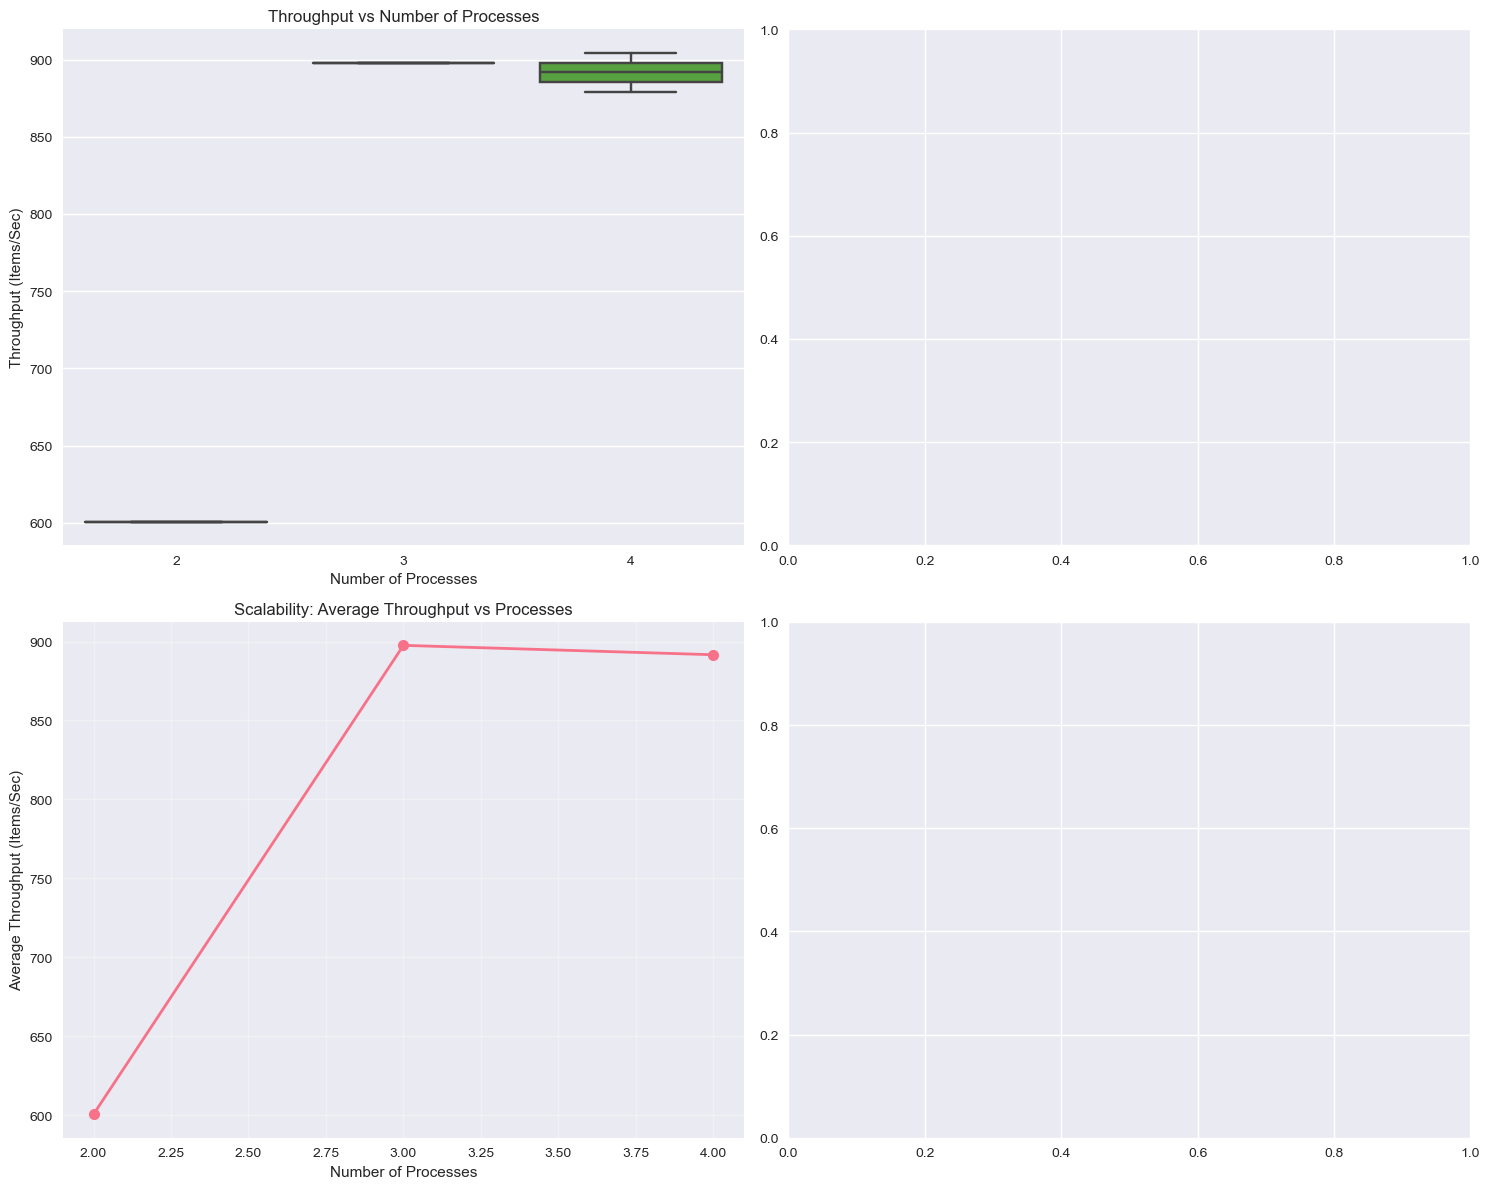


⚡ 2. LATENCY ANALYSIS


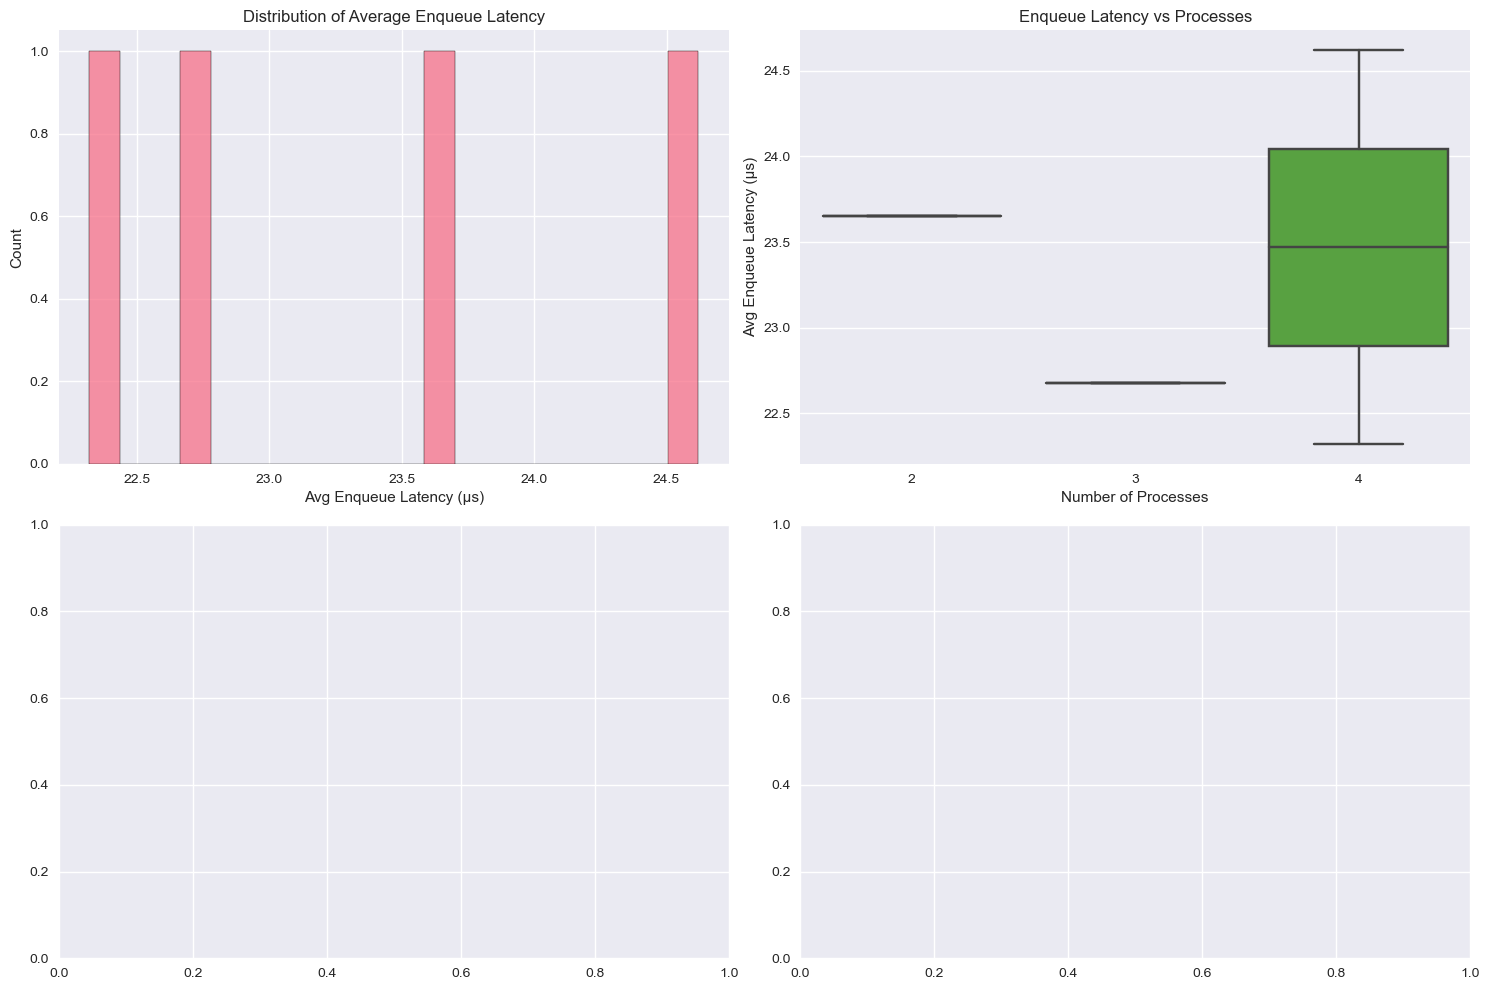


🧪 3. EXPERIMENT COMPARISON

🔗 4. CORRELATION ANALYSIS


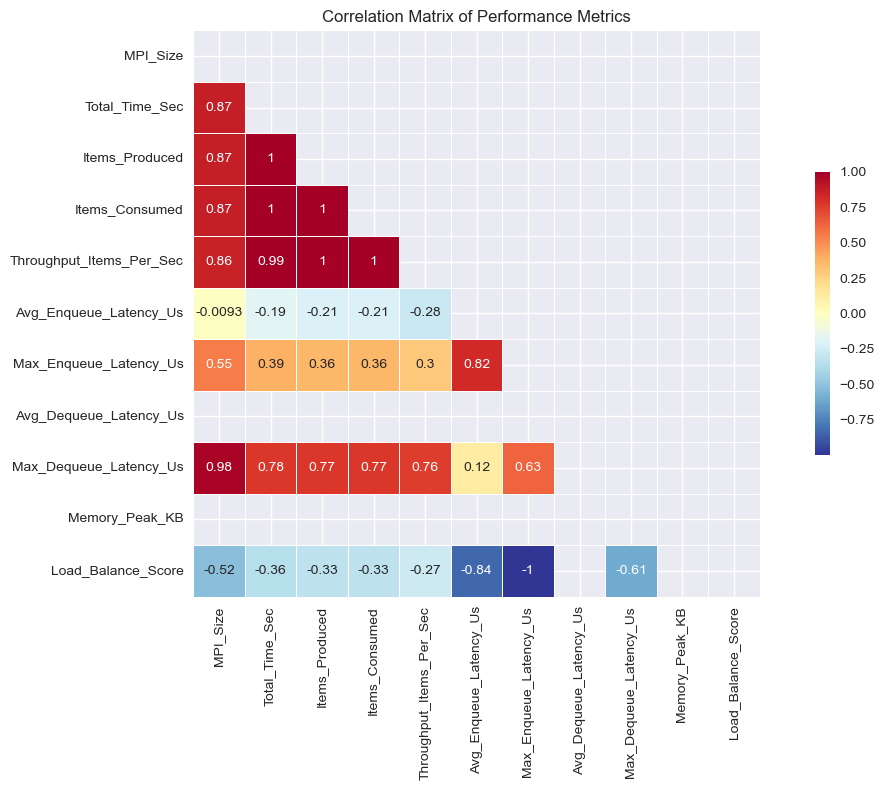


📊 STRONG CORRELATIONS (|r| > 0.5):
  • Items_Produced ↔ Items_Consumed: 1.000
  • Total_Time_Sec ↔ Items_Consumed: 1.000
  • Total_Time_Sec ↔ Items_Produced: 1.000
  • Max_Enqueue_Latency_Us ↔ Load_Balance_Score: -0.999
  • Items_Produced ↔ Throughput_Items_Per_Sec: 0.997
  • Items_Consumed ↔ Throughput_Items_Per_Sec: 0.997
  • Total_Time_Sec ↔ Throughput_Items_Per_Sec: 0.995
  • MPI_Size ↔ Max_Dequeue_Latency_Us: 0.984
  • MPI_Size ↔ Total_Time_Sec: 0.874
  • MPI_Size ↔ Items_Produced: 0.870
  • MPI_Size ↔ Items_Consumed: 0.870
  • MPI_Size ↔ Throughput_Items_Per_Sec: 0.859
  • Avg_Enqueue_Latency_Us ↔ Load_Balance_Score: -0.840
  • Avg_Enqueue_Latency_Us ↔ Max_Enqueue_Latency_Us: 0.821
  • Total_Time_Sec ↔ Max_Dequeue_Latency_Us: 0.781
  • Items_Produced ↔ Max_Dequeue_Latency_Us: 0.775
  • Items_Consumed ↔ Max_Dequeue_Latency_Us: 0.775
  • Throughput_Items_Per_Sec ↔ Max_Dequeue_Latency_Us: 0.756
  • Max_Enqueue_Latency_Us ↔ Max_Dequeue_Latency_Us: 0.632
  • Max_Dequeue_Latency_Us ↔ 

In [13]:
if df_combined is not None and len(df_combined) > 0:
    
    # 5.1 Throughput Analysis
    print("🚀 1. THROUGHPUT ANALYSIS")
    print("=" * 30)
    
    if 'Throughput_Items_Per_Sec' in df_combined.columns and 'MPI_Size' in df_combined.columns:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Throughput vs Processes
        sns.boxplot(data=df_combined, x='MPI_Size', y='Throughput_Items_Per_Sec', ax=axes[0,0])
        axes[0,0].set_title('Throughput vs Number of Processes')
        axes[0,0].set_xlabel('Number of Processes')
        axes[0,0].set_ylabel('Throughput (Items/Sec)')
        
        # Throughput by Experiment
        if 'Experiment_ID' in df_combined.columns:
            plt.figure(figsize=(12, 6))
            sns.barplot(data=df_combined, x='Experiment_ID', y='Throughput_Items_Per_Sec')
            plt.title('Throughput by Experiment')
            plt.xlabel('Experiment')
            plt.ylabel('Throughput (Items/Sec)')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        
        # Scalability Line Plot
        scalability_data = df_combined.groupby('MPI_Size')['Throughput_Items_Per_Sec'].mean().reset_index()
        axes[1,0].plot(scalability_data['MPI_Size'], scalability_data['Throughput_Items_Per_Sec'], 
                      marker='o', linewidth=2, markersize=8)
        axes[1,0].set_title('Scalability: Average Throughput vs Processes')
        axes[1,0].set_xlabel('Number of Processes')
        axes[1,0].set_ylabel('Average Throughput (Items/Sec)')
        axes[1,0].grid(True, alpha=0.3)
        
        # Total Time vs Throughput (colored by experiment)
        if 'Total_Time_Sec' in df_combined.columns and 'Experiment_ID' in df_combined.columns:
            # Create numeric mapping for experiments
            exp_mapping = {exp: i for i, exp in enumerate(df_combined['Experiment_ID'].unique())}
            df_combined['Exp_Numeric'] = df_combined['Experiment_ID'].map(exp_mapping)
            
            scatter = axes[1,1].scatter(df_combined['Total_Time_Sec'], df_combined['Throughput_Items_Per_Sec'], 
                                      c=df_combined['Exp_Numeric'], cmap='Set1', alpha=0.7, s=60)
            axes[1,1].set_title('Total Time vs Throughput (colored by Experiment)')
            axes[1,1].set_xlabel('Total Time (Seconds)')
            axes[1,1].set_ylabel('Throughput (Items/Sec)')
        
        plt.tight_layout()
        plt.show()
    
    # 5.2 Latency Analysis
    print("\n⚡ 2. LATENCY ANALYSIS")
    print("=" * 25)
    
    latency_cols = ['Avg_Enqueue_Latency_Us', 'Max_Enqueue_Latency_Us', 
                   'Avg_Dequeue_Latency_Us', 'Max_Dequeue_Latency_Us']
    available_latency = [col for col in latency_cols if col in df_combined.columns]
    
    if available_latency:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Enqueue Latency Distribution
        if 'Avg_Enqueue_Latency_Us' in df_combined.columns:
            sns.histplot(data=df_combined, x='Avg_Enqueue_Latency_Us', bins=20, ax=axes[0,0])
            axes[0,0].set_title('Distribution of Average Enqueue Latency')
            axes[0,0].set_xlabel('Avg Enqueue Latency (μs)')
        
        # Latency vs Processes
        if 'Avg_Enqueue_Latency_Us' in df_combined.columns:
            sns.boxplot(data=df_combined, x='MPI_Size', y='Avg_Enqueue_Latency_Us', ax=axes[0,1])
            axes[0,1].set_title('Enqueue Latency vs Processes')
            axes[0,1].set_xlabel('Number of Processes')
            axes[0,1].set_ylabel('Avg Enqueue Latency (μs)')
        
        # Latency by Experiment
        if 'Avg_Enqueue_Latency_Us' in df_combined.columns and 'Experiment_ID' in df_combined.columns:
            sns.barplot(data=df_combined, x='Experiment_ID', y='Avg_Enqueue_Latency_Us', ax=axes[1,0])
            axes[1,0].set_title('Enqueue Latency by Experiment')
            axes[1,0].set_xlabel('Experiment')
            axes[1,0].set_ylabel('Avg Enqueue Latency (μs)')
            axes[1,0].tick_params(axis='x', rotation=45)
        
        # Latency vs Throughput Trade-off
        if 'Avg_Enqueue_Latency_Us' in df_combined.columns and 'Throughput_Items_Per_Sec' in df_combined.columns:
            if 'Exp_Numeric' in df_combined.columns:
                scatter = axes[1,1].scatter(df_combined['Avg_Enqueue_Latency_Us'], df_combined['Throughput_Items_Per_Sec'], 
                                          c=df_combined['Exp_Numeric'], cmap='Set1', alpha=0.7, s=60)
                axes[1,1].set_title('Latency vs Throughput Trade-off')
                axes[1,1].set_xlabel('Avg Enqueue Latency (μs)')
                axes[1,1].set_ylabel('Throughput (Items/Sec)')
        
        plt.tight_layout()
        plt.show()
    
    # 5.3 Experiment Comparison
    print("\n🧪 3. EXPERIMENT COMPARISON")
    print("=" * 30)
    
    if 'Experiment_ID' in df_combined.columns and len(df_combined['Experiment_ID'].unique()) > 1:
        # Performance radar chart cho top experiments
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Performance metrics comparison
        metrics_to_compare = ['Throughput_Items_Per_Sec', 'Avg_Enqueue_Latency_Us', 'Load_Balance_Score']
        available_compare_metrics = [col for col in metrics_to_compare if col in df_combined.columns]
        
        if available_compare_metrics:
            exp_comparison = df_combined.groupby('Experiment_ID')[available_compare_metrics].mean()
            
            # Normalize data for better comparison (0-1 scale)
            exp_comparison_norm = exp_comparison.copy()
            for col in exp_comparison_norm.columns:
                if col == 'Avg_Enqueue_Latency_Us':  # Lower is better for latency
                    exp_comparison_norm[col] = 1 - (exp_comparison_norm[col] - exp_comparison_norm[col].min()) / (exp_comparison_norm[col].max() - exp_comparison_norm[col].min() + 1e-8)
                else:  # Higher is better
                    exp_comparison_norm[col] = (exp_comparison_norm[col] - exp_comparison_norm[col].min()) / (exp_comparison_norm[col].max() - exp_comparison_norm[col].min() + 1e-8)
            
            # Plot normalized comparison
            exp_comparison_norm.plot(kind='bar', ax=axes[0])
            axes[0].set_title('Normalized Performance Comparison\n(Higher = Better)')
            axes[0].set_xlabel('Experiment')
            axes[0].set_ylabel('Normalized Score (0-1)')
            axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            axes[0].tick_params(axis='x', rotation=45)
        
        # MPI Size distribution
        if 'MPI_Size' in df_combined.columns:
            exp_mpi = df_combined.groupby('Experiment_ID')['MPI_Size'].first()
            exp_mpi.plot(kind='bar', ax=axes[1])
            axes[1].set_title('MPI Size by Experiment')
            axes[1].set_xlabel('Experiment')
            axes[1].set_ylabel('Number of Processes')
            axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    # 5.4 Correlation Matrix
    print("\n🔗 4. CORRELATION ANALYSIS")
    print("=" * 30)
    
    numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
    # Remove our artificial numeric columns
    numeric_cols = [col for col in numeric_cols if col != 'Exp_Numeric']
    
    if len(numeric_cols) > 1:
        plt.figure(figsize=(12, 8))
        correlation_matrix = df_combined[numeric_cols].corr()
        
        # Mask for upper triangle
        mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
        
        sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
                   square=True, linewidths=0.5, cbar_kws={"shrink": .5})
        plt.title('Correlation Matrix of Performance Metrics')
        plt.tight_layout()
        plt.show()
        
        # Find strong correlations
        corr_pairs = []
        for i in range(len(correlation_matrix.columns)):
            for j in range(i+1, len(correlation_matrix.columns)):
                corr_val = correlation_matrix.iloc[i, j]
                if abs(corr_val) > 0.5:  # Only strong correlations
                    corr_pairs.append((correlation_matrix.columns[i], 
                                     correlation_matrix.columns[j], 
                                     corr_val))
        
        if corr_pairs:
            print("\n📊 STRONG CORRELATIONS (|r| > 0.5):")
            for col1, col2, corr in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True):
                print(f"  • {col1} ↔ {col2}: {corr:.3f}")
    
else:
    print("❌ Không có dữ liệu để visualization!")

# 6. Kết Luận và Khuyến Nghị

## Cách sử dụng notebook này:

1. **Chạy tuần tự từ trên xuống**: Bắt đầu từ cell import libraries
2. **Kiểm tra path**: Đảm bảo thư mục `benchmark/results` có dữ liệu CSV
3. **Thêm dữ liệu mới**: Sau khi chạy benchmark mới, chỉ cần re-run từ cell load data

## Phân tích từ dữ liệu hiện tại:

### 📈 Performance Insights sẽ hiển thị:
- **Scalability**: Hiệu suất tăng như thế nào khi tăng số processes
- **Bottlenecks**: Phát hiện điểm nghẽn trong hệ thống
- **Optimal Configuration**: Tìm cấu hình tốt nhất cho use case cụ thể

### ⚡ Latency Analysis:
- **Trade-offs**: Mối quan hệ giữa throughput và latency
- **Consistency**: Độ ổn định của performance qua các lần chạy

### ⚖️ Load Balancing:
- **Efficiency**: Hiệu quả phân phối tải giữa các consumer
- **Resource Utilization**: Mức độ sử dụng tài nguyên

## 🎯 Khuyến nghị sử dụng:

1. **Chạy benchmark với nhiều cấu hình khác nhau** để có dataset phong phú hơn
2. **Monitor memory usage** nếu có dữ liệu về memory
3. **So sánh với baseline** để đánh giá cải tiến
4. **Automated testing** tích hợp vào CI/CD pipeline

In [14]:
# Utility functions để sử dụng sau này

def export_summary_report(df, filename="benchmark_summary_report.txt"):
    """Export summary report to text file"""
    if df is not None:
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("SPMC BENCHMARK ANALYSIS REPORT\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Total Records: {len(df)}\n\n")
            
            # Key metrics summary
            key_metrics = ['Total_Time_Sec', 'Throughput_Items_Per_Sec', 'Avg_Enqueue_Latency_Us']
            available_metrics = [col for col in key_metrics if col in df.columns]
            
            if available_metrics:
                f.write("KEY METRICS SUMMARY:\n")
                f.write("-" * 25 + "\n")
                summary = df[available_metrics].describe()
                f.write(summary.to_string())
                f.write("\n\n")
            
            # Performance by processes
            if 'MPI_Size' in df.columns:
                f.write("PERFORMANCE BY PROCESS COUNT:\n")
                f.write("-" * 35 + "\n")
                process_perf = df.groupby('MPI_Size')[available_metrics].mean()
                f.write(process_perf.to_string())
                f.write("\n\n")
        
        print(f"✅ Summary report exported to: {filename}")
    else:
        print("❌ No data to export!")

def compare_configurations(df, config1_filter, config2_filter, config1_name="Config 1", config2_name="Config 2"):
    """Compare two different configurations"""
    if df is not None:
        data1 = df[config1_filter]
        data2 = df[config2_filter]
        
        print(f"🔍 COMPARISON: {config1_name} vs {config2_name}")
        print("=" * 50)
        
        key_metrics = ['Throughput_Items_Per_Sec', 'Avg_Enqueue_Latency_Us', 'Total_Time_Sec']
        available_metrics = [col for col in key_metrics if col in df.columns]
        
        comparison = pd.DataFrame({
            config1_name: data1[available_metrics].mean(),
            config2_name: data2[available_metrics].mean()
        })
        comparison['Improvement_%'] = ((comparison[config2_name] - comparison[config1_name]) / comparison[config1_name] * 100).round(2)
        
        display(comparison)
        
        return comparison
    else:
        print("❌ No data for comparison!")
        return None

# Example usage functions
print("🛠️ UTILITY FUNCTIONS LOADED:")
print("• export_summary_report(df, filename)")
print("• compare_configurations(df, filter1, filter2, name1, name2)")
print("\nSẵn sàng để phân tích dữ liệu benchmark! 🚀")

🛠️ UTILITY FUNCTIONS LOADED:
• export_summary_report(df, filename)
• compare_configurations(df, filter1, filter2, name1, name2)

Sẵn sàng để phân tích dữ liệu benchmark! 🚀
